In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report

# Charger IMDB
dataset = load_dataset("stanfordnlp/imdb")
train_data = dataset["train"]
test_data = dataset["test"]

C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Texte brut (garde la ponctuation, les majuscules — sklearn gère)
train_texts = [r['text'] for r in train_data]
train_labels = [r['label'] for r in train_data]
test_texts = [r['text'] for r in test_data]
test_labels = [r['label'] for r in test_data]

In [3]:
# Unigram
vec_uni = CountVectorizer(max_features=10000, ngram_range=(1,1))
X_train_uni = vec_uni.fit_transform(train_texts)
X_test_uni = vec_uni.transform(test_texts)

# Bigram
vec_bi = CountVectorizer(max_features=10000, ngram_range=(1,2))
X_train_bi = vec_bi.fit_transform(train_texts)
X_test_bi = vec_bi.transform(test_texts)

In [8]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = {'C': [], 'train_uni': [], 'test_uni': [], 'train_bi': [], 'test_bi': []}

for C in C_values:
    # Unigramclf_uni = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf_uni = LogisticRegression(C=C, max_iter=200)
    clf_uni.fit(X_train_uni, train_labels)
    results['train_uni'].append(accuracy_score(train_labels, clf_uni.predict(X_train_uni)))
    results['test_uni'].append(accuracy_score(test_labels, clf_uni.predict(X_test_uni)))
    
    # Bigram
    clf_bi = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf_bi.fit(X_train_bi, train_labels)
    results['train_bi'].append(accuracy_score(train_labels, clf_bi.predict(X_train_bi)))
    results['test_bi'].append(accuracy_score(test_labels, clf_bi.predict(X_test_bi)))
    
    results['C'].append(C)
    print(f"C={C:.3f} | Uni train={results['train_uni'][-1]:.3f} test={results['test_uni'][-1]:.3f} | Bi train={results['train_bi'][-1]:.3f} test={results['test_bi'][-1]:.3f}")

C=0.001 | Uni train=0.864 test=0.849 | Bi train=0.875 test=0.858


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.010 | Uni train=0.916 test=0.881 | Bi train=0.924 test=0.889


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.100 | Uni train=0.960 test=0.875 | Bi train=0.936 test=0.892


...

C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=10.000 | Uni train=0.996 test=0.840 | Bi train=0.937 test=0.892


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=100.000 | Uni train=0.991 test=0.840 | Bi train=0.937 test=0.892


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


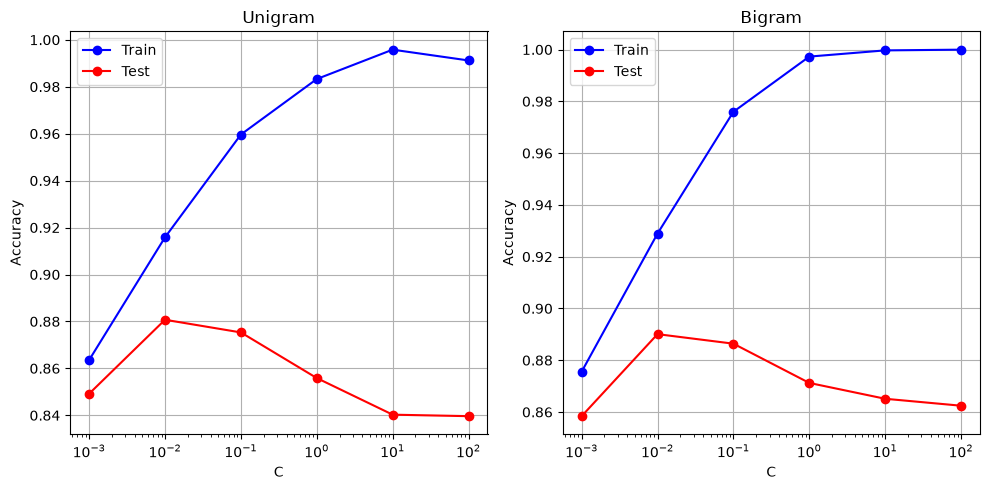

In [5]:
plt.figure(figsize=(10,5))

# Unigram
plt.subplot(1,2,1)
plt.semilogx(results['C'], results['train_uni'], 'b-o', label='Train')
plt.semilogx(results['C'], results['test_uni'], 'r-o', label='Test')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Unigram')
plt.legend()
plt.grid(True)

# Bigram
plt.subplot(1,2,2)
plt.semilogx(results['C'], results['train_bi'], 'b-o', label='Train')
plt.semilogx(results['C'], results['test_bi'], 'r-o', label='Test')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Bigram')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Meilleur modèle bigram
best_C = C_values[np.argmax(results['test_bi'])]
print(f"Meilleur C : {best_C}")

clf_best = LogisticRegression(C=best_C, max_iter=200)
clf_best.fit(X_train_bi, train_labels)
preds = clf_best.predict(X_test_bi)

print(f"\nAccuracy finale : {accuracy_score(test_labels, preds):.4f}")
print(classification_report(test_labels, preds, target_names=['Négatif', 'Positif']))

# Gain bigram vs unigram
best_uni = max(results['test_uni'])
best_bi = max(results['test_bi'])
print(f"\nGain bigram vs unigram : {(best_bi - best_uni)*100:.1f}%")

Meilleur C : 0.01

Accuracy finale : 0.8901
              precision    recall  f1-score   support

     Négatif       0.90      0.88      0.89     12500
     Positif       0.88      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000


Gain bigram vs unigram : 0.9%


# 📋 RÉSUMÉ TP 3 — Régression Logistique sur Features Texte

---

## 🧠 LA MENTALITÉ

> La régression logistique apprend **un poids par mot**. Elle capture les corrélations (contrairement à Naive Bayes), mais sans régularisation, elle overfit sur les mots rares. **C** contrôle la force de la régularisation : petit C = forte, grand C = faible.

---

## 📖 C'EST QUOI LA RÉGRESSION LOGISTIQUE ?

Chaque mot reçoit un **poids** (positif ou négatif). Pour classer un texte, on additionne les poids des mots présents :

| Mot | Poids |
|-----|-------|
| `excellent` | +3.2 |
| `terrible` | -4.1 |
| `movie` | +0.1 |
| `not` | -1.5 |

```
"excellent movie" = +3.2 + 0.1 = +3.3 → POSITIF ✅
"terrible movie"  = -4.1 + 0.1 = -4.0 → NÉGATIF ✅
```

---

## ⚖️ C'EST QUOI LA RÉGULARISATION (C) ?

**Problème :** Sans régularisation, un mot rare (ex: `antwone` vu 1 fois) peut avoir un poids énorme (+100) et fausser toutes les prédictions.

**Solution :** La régularisation L2 empêche les poids trop grands.

| C | Régularisation | Effet |
|----|---------------|-------|
| 0.001 | **Forte** | Poids petits, pas d'overfit, sous-apprend peut-être |
| 0.01-0.1 | **Bonne** | Équilibre train/test |
| 1-10 | **Faible** | Risque d'overfit |
| 100 | **Très faible** | Apprend par cœur, mauvais en test |

**Analogie :** Un élastique tire tous les poids vers 0. C = la force inverse. Petit C = élastique fort.

---

## 📊 OVERFITTING VISIBLE (TES RÉSULTATS)

| C | Train | Test | Écart | Diagnostic |
|----|-------|------|-------|------------|
| 0.01 | 91.6% | **88.1%** | 3.5% | ✅ Bon équilibre |
| 1 | 98.3% | 85.6% | 12.7% | ⚠️ Sur-apprend |
| 100 | 99.1% | 84.0% | 15.1% | ❌ Overfit sévère |

**Quand C augmente :** train monte, test descend = **signature de l'overfitting**.

---

## 🔤 BIGRAM VS UNIGRAM

| Type | "not good" devient | Poids appris |
|------|-------------------|--------------|
| Unigram | `not`, `good` | 2 poids séparés → neutre |
| Bigram | `not_good` | 1 poids → fortement négatif |

Le bigram capture la **négation** qu'un unigram ne voit pas.

**Résultat :** Bigram (89.0%) > Unigram (88.1%) de +0.9%.

---

## 💻 CHAQUE LIGNE EXPLIQUÉE

### Imports
```python
import re                          # Regex (non utilisé ici mais dispo)
import numpy as np                 # Calculs numériques
import matplotlib.pyplot as plt    # Tracer des graphiques
from datasets import load_dataset  # Télécharger IMDB
from sklearn.linear_model import LogisticRegression  # Le modèle
from sklearn.feature_extraction.text import CountVectorizer  # Transformer texte → nombres
from sklearn.metrics import accuracy_score, classification_report  # Métriques
```

### Charger les données
```python
dataset = load_dataset("stanfordnlp/imdb")  # Télécharge IMDB depuis HuggingFace
train_data = dataset["train"]               # 25k reviews étiquetées
test_data = dataset["test"]                 # 25k reviews étiquetées

train_texts = [r['text'] for r in train_data]   # Extraire le texte
train_labels = [r['label'] for r in train_data] # Extraire les labels (0 ou 1)
test_texts = [r['text'] for r in test_data]
test_labels = [r['label'] for r in test_data]
```

### Vectorizer : transformer le texte en nombres
```python
# CountVectorizer = Bag-of-Words automatique
# max_features=10000 : garde les 10k mots les plus fréquents
# ngram_range=(1,1) : unigrams seulement
# ngram_range=(1,2) : unigrams + bigrams
# fit_transform : apprend le vocabulaire ET transforme le train
# transform : applique le MÊME vocabulaire au test

vec_uni = CountVectorizer(max_features=10000, ngram_range=(1,1))
X_train_uni = vec_uni.fit_transform(train_texts)  # Matrice 25000 × 10000
X_test_uni = vec_uni.transform(test_texts)        # Matrice 25000 × 10000
```

### Entraîner la régression logistique
```python
clf = LogisticRegression(
    C=0.1,           # Force de régularisation (petit = forte)
    max_iter=500,    # Nombre max d'itérations pour converger
    solver='saga'    # Algorithme qui gère bien les gros datasets
)
clf.fit(X_train_uni, train_labels)  # Apprend les poids de chaque mot
preds = clf.predict(X_test_uni)     # Prédit sur le test
```

### Évaluer
```python
accuracy = accuracy_score(test_labels, preds)  # % de bonnes réponses
print(classification_report(test_labels, preds))  # Précision, rappel, F1
```

### Tracer la courbe
```python
plt.semilogx(C_values, train_scores, 'b-o', label='Train')  # Courbe bleue
plt.semilogx(C_values, test_scores, 'r-o', label='Test')    # Courbe rouge
plt.xlabel('C (échelle log)')   # Axe X en log
plt.ylabel('Accuracy')          # Axe Y
plt.legend()                    # Affiche la légende
plt.grid(True)                  # Affiche la grille
plt.show()                      # Montre le graphique
```

---

## 🎯 CAS PRATIQUE : Tu dois classer des tweets

```python
# 1. Charger tes données
tweets = ["I love this product", "Worst experience ever", "Not bad at all"]
labels = [1, 0, 1]  # 1=positif, 0=négatif

# 2. Vectorizer
vec = CountVectorizer(ngram_range=(1,2))  # Unigrams + bigrams
X = vec.fit_transform(tweets)

# 3. Entraîner
clf = LogisticRegression(C=0.1, max_iter=500)
clf.fit(X, labels)

# 4. Prédire un nouveau tweet
new = ["I don't like it"]
X_new = vec.transform(new)
pred = clf.predict(X_new)  # 0 ou 1
proba = clf.predict_proba(X_new)  # [[prob_neg, prob_pos]]

print(f"Prédiction : {'Positif' if pred[0]==1 else 'Négatif'}")
print(f"Confiance : {proba[0][pred[0]]*100:.1f}%")

# 5. Voir les poids des mots
for word, weight in zip(vec.get_feature_names_out(), clf.coef_[0]):
    if abs(weight) > 0.5:  # Affiche seulement les mots influents
        print(f"{word}: {weight:+.2f}")
```

---

## ✅ CE QUE J'AI APPRIS

1. La régression logistique = un poids par mot, on additionne
2. `CountVectorizer` = Bag-of-Words automatique
3. `C` contrôle la régularisation (petit C = forte)
4. L'overfitting se voit quand train >> test
5. Les bigrams capturent les négations (`not_good`)
6. `fit_transform` pour le train, `transform` pour le test
7. `predict_proba` donne la confiance du modèle
8. `coef_` contient les poids appris pour chaque mot